# CNN Image Classification Laboration


Images used in this laboration are from [CIFAR10](https://en.wikipedia.org/wiki/CIFAR-10). The CIFAR10 dataset contains 60,000 32x32 color images in 10 different classes. The 10 different classes represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. There are 6,000 images of each class. 

Your task is to make a classifier, using a convolutional neural network, that can correctly classify each image into the correct class.

Complete the code flagged throughout the elaboration and **answer all the questions in the notebook**.

In [2]:
# Setups
# Automatically reload modules when changed
%reload_ext autoreload
%autoreload 2

# Part 1: Convolutions

In the next sections you will familiarize yourself with 2D convolutions.

## 1.1 What is a convolution?

To understand a bit more about convolutions, we will first test the convolution function in `scipy` using a number of classical filters. 

Convolve the image with Gaussian filter, a Sobel X filter, and a Sobel Y filter, using the function `convolve2d` in `signal` from scipy (see the [documentation](https://docs.scipy.org/doc/scipy-1.15.0/reference/generated/scipy.signal.convolve2d.html
) for more details).


In a CNN, many filters are applied in each layer, and the filter coefficients are learned through back propagation (which is in contrast to traditional image processing, where the filters are designed by an expert).

Run the cell below to define a Gaussian filter and a Sobel X and Y filters.

In [3]:
from scipy import signal
import numpy as np

# Get a test image
from scipy import datasets
image = datasets.ascent()

# Define a help function for creating a Gaussian filter
def matlab_style_gauss2D(shape=(3,3),sigma=0.5):
    """
    2D gaussian mask - should give the same result as MATLAB's
    fspecial('gaussian',[shape],[sigma])
    """
    m,n = [(ss-1.)/2. for ss in shape]
    y,x = np.ogrid[-m:m+1,-n:n+1]
    h = np.exp( -(x*x + y*y) / (2.*sigma*sigma) )
    h[ h < np.finfo(h.dtype).eps*h.max() ] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

# Create Gaussian filter with certain size and standard deviation
gaussFilter = matlab_style_gauss2D((15,15),4)

# Define filter kernels for SobelX and Sobely
sobelX = np.array([[ 1, 0,  -1],
                    [2, 0, -2],
                    [1, 0, -1]]) 

sobelY = np.array([[ 1, 2,  1],
                    [0, 0, 0],
                    [-1, -2, -1]]) 

In [4]:
# --------------------------------------------
# === Your code here =========================
# -------------------------------------------- 
# Perform convolution using the function 'convolve2d' for the different filters

filterResponseGauss = signal.convolve2d(image, gaussFilter, mode = "full")
filterResponseSobelX = signal.convolve2d(image, sobelX, mode = "full")
filterResponseSobelY = signal.convolve2d(image, sobelY, mode = "full")

# ============================================

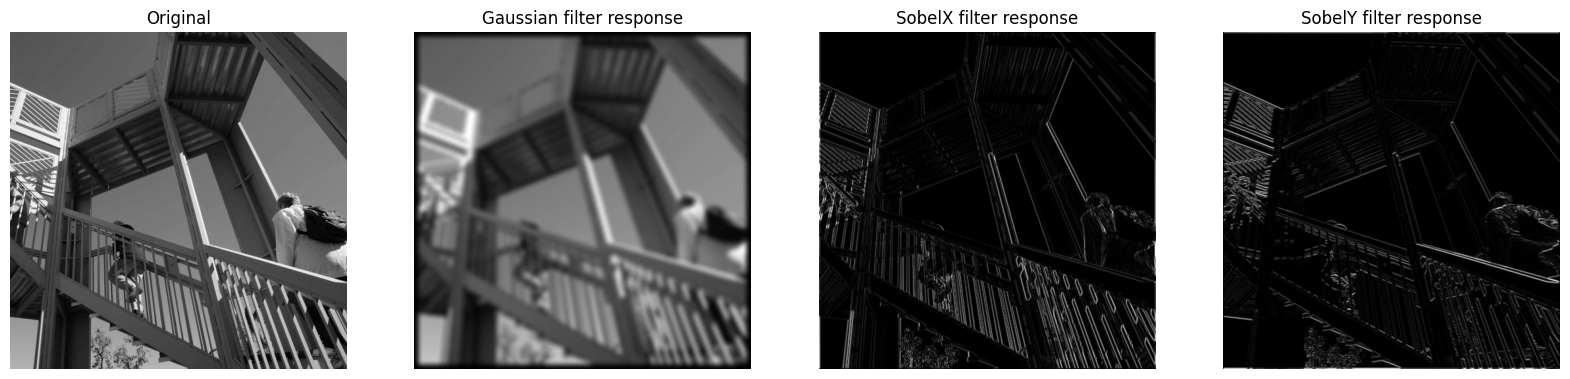

In [5]:
import matplotlib.pyplot as plt

# Show filter responses
fig, (ax_orig, ax_filt1, ax_filt2, ax_filt3) = plt.subplots(1, 4, figsize=(20, 6))
ax_orig.imshow(image, cmap='gray')
ax_orig.set_title('Original')
ax_orig.set_axis_off()
ax_filt1.imshow(np.absolute(filterResponseGauss), cmap='gray')
ax_filt1.set_title('Gaussian filter response')
ax_filt1.set_axis_off()
ax_filt2.imshow(np.absolute(filterResponseSobelX), cmap='gray')
ax_filt2.set_title('SobelX filter response')
ax_filt2.set_axis_off()
ax_filt3.imshow(np.absolute(filterResponseSobelY), cmap='gray')
ax_filt3.set_title('SobelY filter response')
ax_filt3.set_axis_off()

In [6]:
image.shape

(512, 512)

## 1.2 Understanding convolutions

#### **<span style="color:red">Questions</span>**

1. What do the 3 different filters (Gaussian, SobelX, SobelY) do to the original image?

2. What is the size of the original image? How many channels does it have? How many channels does a color image normally have?

3. What is the size of the different filters?

4. What is the size of the filter response if mode 'same' is used for the convolution ?

5. What is the size of the filter response if mode 'valid' is used for the convolution? How does the size of the valid filter response depend on the size of the filter? 

6. Why are 'valid' convolutions a problem for CNNs with many layers?

#### **<span style="color:green">Answers</span>**
1. Gaussian filter: Smoothing the image and blurs edges.  
SobelX filter: Change intensity on edges with vertical direction.  
SobelY filter: Change intensity on edges with horizotal direction.  
  
2. The size: 512x512. Thr image has one channel since it is in grayscale. Coloured images usually have three Channels, RGB.  
  
3. Gaussian filter size: 15x15. SobelX: 3x3. SobelY: 3x3.  
  
4. With "same" the output will have the same output size as the input image.  
  
5. With "valid" the output size will shrink. If the image is H × W and the filter is kH × kW, then the valid output size is: (H - kH + 1) x (W - kW + 1).
  
6. Because of its shrinking nature, stacking layers will shrink the images to become too small and removing border information too early.

In [7]:
# --------------------------------------------
# === Your code here =========================
# -------------------------------------------- 
# Your code for checking sizes of image and filter responses
print("Size of image =", image.shape)
print("Size of Gauss Response =", filterResponseGauss.shape)
print("Size of Response SobelX=", filterResponseSobelX.shape)
print("Size of Response SobelY =", filterResponseSobelX.shape)

# ============================================

Size of image = (512, 512)
Size of Gauss Response = (526, 526)
Size of Response SobelX= (514, 514)
Size of Response SobelY = (514, 514)


#  Part 2: Get a graphics card

Skip the next cell if you run on the CPU.

If your computer has a dedicated graphics card and you would like to use it, we need to make sure that our script can see the graphics card that will be used. The graphics cards will perform all the time consuming calculations in every training iteration.

In [8]:
import os
import warnings

# Ignore FutureWarning from numpy
warnings.simplefilter(action='ignore', category=FutureWarning)

import tensorflow as tf

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
 
# The GPU id to use, usually either "0" or "1";
os.environ["CUDA_VISIBLE_DEVICES"]="0"

# This sets the GPU to allocate memory only as needed
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) != 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True) 
    print("Running on GPU")
else:
    print('No GPU available.')

No GPU available.


## How fast is the graphics card?


#### **<span style="color:red">Questions</span>**

7. Why are the filters used for a color image of size 7 x 7 x 3, and not 7 x 7 ? 

8. What operation is performed by the 'Conv2D' layer? Is it a standard 2D convolution, as performed by the function signal.convolve2d we just tested?

9.  Pretend that everyone is using an Nvidia RTX 3090 graphics card, how many CUDA cores does it have? How much memory does the graphics card have?

10. How much memory does the graphics card have?

11. What is stored in the GPU memory while training a CNN?

12. Do you think that a graphics card, compared to the CPU, is equally faster for convolving a batch of 1,000 images, compared to convolving a batch of 3 images? Motivate your answer.


#### **<span style="color:green">Answers</span>**
7. As mentioned previously, coloured pictures use three channels (RGB). Therefore it will be 7x7x3.  
  
8. A 'Conv2D' layer performs cross‑correlation, while signal.convolve2d performs actual convolution. The differences between are how they handle the kernel. Actual convolution flips it, while cross-correlation does not flip it.
  
9. CUDA cores: 10,496 and 24 GB memory

10. 24 GB GDDR6X

11. The GPU memory stores model parameters, gradients, training batches and activations for every layer

12. GPUs are faster when doing several hundreds/thousands operation in parallel. Therefore it will be faster than CPU when convolving 1000 images, but less efficient when only convolving a batch of three images, since most cores will be idle. 

# Part 3: Dataset

In the following section you will load the CIFAR10 dataset, check few samples, perform some preprocessing on the images and the labels, and split the data into training, validation and testing.

## 3.1 Load the dataset

Run the following section to load the CIFAR10 data, take a total of 10.000 training/validation samples and 2000 testing samples. 

In [9]:
from keras.datasets import cifar10
import numpy as np

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Download CIFAR train and test data
(X, Y), (Xtest, Ytest) = cifar10.load_data()

print("Training/validation images have size {} and labels have size {} ".format(X.shape, Y.shape))
print("Test images have size {} and labels have size {} \n ".format(Xtest.shape, Ytest.shape))

# Reduce the number of images for training/validation and testing to 10000 and 2000 respectively, 
# to reduce processing time for this elaboration. 
X = X[0:10000]
Y = Y[0:10000]

Xtest = Xtest[0:2000]
Ytest = Ytest[0:2000]

Ytestint = Ytest

print("Reduced training/validation images have size %s and labels have size %s " % (X.shape, Y.shape))
print("Reduced test images have size %s and labels have size %s \n" % (Xtest.shape, Ytest.shape))

# Check that we have some training examples from each class
for i in range(10):
    print("Number of training/validation examples for class {} is {}" .format(i,np.sum(Y == i)))

Training/validation images have size (50000, 32, 32, 3) and labels have size (50000, 1) 
Test images have size (10000, 32, 32, 3) and labels have size (10000, 1) 
 
Reduced training/validation images have size (10000, 32, 32, 3) and labels have size (10000, 1) 
Reduced test images have size (2000, 32, 32, 3) and labels have size (2000, 1) 

Number of training/validation examples for class 0 is 1005
Number of training/validation examples for class 1 is 974
Number of training/validation examples for class 2 is 1032
Number of training/validation examples for class 3 is 1016
Number of training/validation examples for class 4 is 999
Number of training/validation examples for class 5 is 937
Number of training/validation examples for class 6 is 1030
Number of training/validation examples for class 7 is 1001
Number of training/validation examples for class 8 is 1025
Number of training/validation examples for class 9 is 981


Lets look at some of the training examples, this cell is already finished. You will see different examples every time you run the cell.

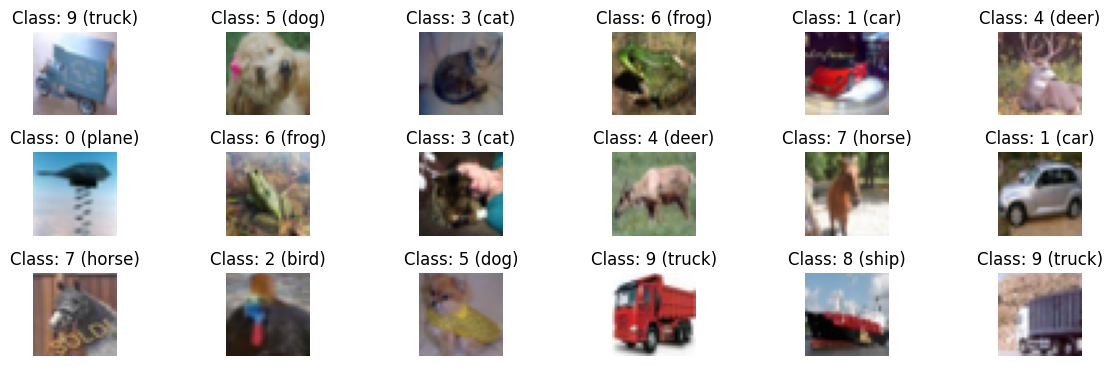

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
for i in range(18):
    idx = np.random.randint(7500)
    label = Y[idx,0]
    
    plt.subplot(3,6,i+1)
    plt.tight_layout()
    plt.imshow(X[idx])
    plt.title("Class: {} ({})".format(label, classes[label]))
    plt.axis('off')
plt.show()

##  3.2 Split data into training, validation and testing
Split your data (X, Y) into training (Xtrain, Ytrain) and validation (Xval, Yval), so that we have training, validation and test datasets (as in the previous laboration).

We use the `train_test_split` function from scikit learn (see the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) for more details) to obtain 25% validation set.

In [11]:
from sklearn.model_selection import train_test_split

# --------------------------------------------
# === Your code here =========================
# --------------------------------------------

# split the original dataset into 70% Training and 30% Temp
Xtrain, Xval, Ytrain, Yval = train_test_split(X, Y, test_size=0.3, random_state=123)



# Print the size of training data, validation data and test data
print("Training data size: ", len(Xtrain))
print("Validation data size: ", len(Xval))
print("Test data size: ", len(Xtest))

# ============================================

Training data size:  7000
Validation data size:  3000
Test data size:  2000


## 3.3 Image Preprocessing

Lets perform some preprocessing. The images are stored as uint8, i.e. 8 bit unsigned integers, but need to be converted to 32 bit floats. We also make sure that the range is -1 to 1, instead of 0 - 255.

In [12]:
# Convert datatype for Xtrain, Xval, Xtest, to float32
Xtrain = Xtrain.astype('float32')
Xval = Xval.astype('float32')
Xtest = Xtest.astype('float32')

# Change range of pixel values to [-1,1]
Xtrain = Xtrain / 127.5 - 1
Xval = Xval / 127.5 - 1
Xtest = Xtest / 127.5 - 1

##  3.4 Label preprocessing

The labels (Y) need to be converted from e.g. '4' to "hot encoded", i.e. to a vector of type [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] . We use the `to_categorical`function in Keras (see the [documentation](https://keras.io/api/utils/python_utils/#to_categorical-function) for details on how to use it)

In [13]:
len(np.unique(Ytrain))

10

In [14]:
from keras.utils import to_categorical

# Print shapes before converting the labels
print('Ytrain has size {}.'.format(Ytrain.shape))
print('Yval has size {}.'.format(Yval.shape))
print('Ytest has size {}.'.format(Ytest.shape))


# --------------------------------------------
# === Your code here =========================
# --------------------------------------------

# Your code for converting Ytrain, Yval, Ytest to categorical
Ytrain = to_categorical(Ytrain, num_classes=10)
Yval = to_categorical(Yval, num_classes=10)
Ytest = to_categorical(Ytest, num_classes=10)

# Print shapes after converting the labels
print('Ytrain has size {}.'.format(Ytrain.shape))
print('Yval has size {}.'.format(Yval.shape))
print('Ytest has size {}.'.format(Ytest.shape))


# ============================================

Ytrain has size (7000, 1).
Yval has size (3000, 1).
Ytest has size (2000, 1).
Ytrain has size (7000, 10).
Yval has size (3000, 10).
Ytest has size (2000, 10).


# Part 4: 2D CNN

In the following sections you will build a 2D CNN model and will train it to perform classification on the CIFAR10 dataset. 

## 4.1 Build CNN model

Start by implementing the `build_CNN` function in the `utilities.py` file. Below you can find the specifications on how your `build_CNN` function should build the model:
- Each convolutional layer is composed by: `2D convolution` -> `batch normalization` -> `max pooling`.
- The `2D convolution` uses a 3 x 3 kernel size, padding='same' and a number of starting filter that is an input to the `build_CNN` function. The number of filters doubles with each convolutional layer (e.g. 32, 64, 128, etc.)
- The max pooling layers should have a pool size of 2 x 2.
- After the convolutional layers comes a flatten layer, followed by a number of intermediate dense layers. 
- The number of nodes in the intermediate dense layers before the final dense layer is an input to the `build_CNN` function. The intermediate dense layers use `relu` activation functions and each is followed by `batch normalization`.
- The final dense layer should have 10 nodes (=the number of classes in this elaboration) and `softmax` activation. 

Here are some relevant functions that you should use in `build_CNN`. For a complete list of functions and their definitions see the [keras documentation](https://keras.io/api/):

- `model.add()`, adds a layer to the network;
- `Dense()`, a dense network layer. See the [documentation](https://keras.io/api/layers/core_layers/dense/) what are the input options and outputs of the `Dense()` function. 
- `Conv2D()` performs 2D convolutions with a number of filters with a certain size (e.g. 3 x 3) (see [documentation](https://keras.io/api/layers/convolution_layers/convolution2d/)). 
- `BatchNormalization()`, perform batch normalization (see [documentation](https://keras.io/api/layers/normalization_layers/batch_normalization/)).
- `MaxPooling2D()`, saves the max for a given pool size, results in down sampling (see [documentation](https://keras.io/api/layers/pooling_layers/max_pooling2d/)).
- `Flatten()`, flatten a multi-channel tensor into a long vector (see [documentation](https://keras.io/api/layers/reshaping_layers/flatten/)).
- `model.compile()`, compiles the model. You can set the input metrics=['accuracy'] to print the classification accuracy during the training.
- cost and loss functions: check the [documentation](https://keras.io/losses/) and chose a loss function for binary classification.

To get more information in model [compile](https://keras.io/api/models/model_training_apis/#compile-method), [training](https://keras.io/api/models/model_training_apis/#fit-method) and [evaluation](https://keras.io/api/models/model_training_apis/#evaluate-method) see the relevant documentation.

Here you can start with the `Adam` optimizer when compiling the model.

Use the following cell to test your `build_CNN` utility function. Remember to import a relevant cost function for multi-class classification from [keras.losses](https://keras.io/losses/) which relates to how many classes you have.

In [15]:
Xtrain.shape

(7000, 32, 32, 3)

In [16]:
# import utilities
from utilities import build_CNN

# --------------------------------------------
# === Your code here =========================
# --------------------------------------------

# import a suitable loss function from keras.losses and use as input to the build_DNN function.
from tf_keras.losses import CategoricalCrossentropy

# Build a DNN model following the specifications above
input_shape = Xtrain.shape[1:]
loss = CategoricalCrossentropy()


model = build_CNN(input_shape=input_shape, loss=loss)

# ============================================

## 4.2 Train 2D CNN

Time to train the CNN!

Start with a model with 2 convolutional layers where the first layer has have 16 filters, and with no intermediate dense layers.

Set the training parameters, build the model and run the training. 

Use the following training parameters:
- `batch_size=20`
- `epochs=20`
- `learning_rate=0.01`

Relevant functions:
- `build_CNN`, the function that you defined in the `utilities.py` file.
- `model.fit()`, train the model with some training data (see [documentation](https://keras.io/api/models/model_training_apis/#fit-method)).
- `model.evaluate()`, apply the trained model to some test data (see [documentation](https://keras.io/api/models/model_training_apis/#evaluate-method)).

## 2 convolutional layers, no intermediate dense layers

In [17]:
Ytrain.shape

(7000, 10)

In [18]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------

# Setup some training parameters
batch_size = 20
epochs = 20
input_shape = Xtrain.shape[1:]
learning_rate = 0.01
n_conv_layers = 2
n_filters = 16
n_dense_layers=0
loss = CategoricalCrossentropy()
validation_data=(Xval, Yval)

# Build model
model = build_CNN(input_shape=input_shape,
                  loss=loss,
                  learning_rate=learning_rate,
                  n_conv_layers=n_conv_layers,
                  n_filters=n_filters,
                  n_dense_layers=n_dense_layers)

# Train the model  using training data and validation data
history1 = model.fit(Xtrain, Ytrain, batch_size=batch_size, epochs=epochs, validation_data=validation_data)

# ============================================

Epoch 1/20


350/350 [==============================] - 4s 8ms/step - loss: 2.0148 - accuracy: 0.3624 - val_loss: 1.6617 - val_accuracy: 0.4190
Epoch 2/20
350/350 [==============================] - 3s 7ms/step - loss: 1.4600 - accuracy: 0.5007 - val_loss: 1.5304 - val_accuracy: 0.4737
Epoch 3/20
350/350 [==============================] - 2s 7ms/step - loss: 1.2621 - accuracy: 0.5630 - val_loss: 1.4662 - val_accuracy: 0.5093
Epoch 4/20
350/350 [==============================] - 2s 7ms/step - loss: 1.1244 - accuracy: 0.6104 - val_loss: 1.3970 - val_accuracy: 0.5307
Epoch 5/20
350/350 [==============================] - 2s 7ms/step - loss: 1.0070 - accuracy: 0.6396 - val_loss: 1.3669 - val_accuracy: 0.5453
Epoch 6/20
350/350 [==============================] - 2s 7ms/step - loss: 0.9140 - accuracy: 0.6789 - val_loss: 1.4030 - val_accuracy: 0.5413
Epoch 7/20
350/350 [==============================] - 2s 7ms/step - loss: 0.8323 - accuracy: 0.7076 - val_loss: 1.4022 - val_accuracy: 0.5423
Epoc

In [19]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------

# Evaluate the trained model on test set, not used in training or validation
test_score = model.evaluate(Xtest, Ytest)

# ============================================

print('Test loss: %.4f' % test_score[0])
print('Test accuracy: %.4f' % test_score[1])

# Train accuracy

train_score = model.evaluate(Xtrain, Ytrain)

# ============================================

print('Train loss: %.4f' % train_score[0])
print('Train accuracy: %.4f' % train_score[1])

63/63 [==============================] - 0s 4ms/step - loss: 1.8636 - accuracy: 0.5650
Test loss: 1.8636
Test accuracy: 0.5650
219/219 [==============================] - 1s 4ms/step - loss: 0.1483 - accuracy: 0.9636
Train loss: 0.1483
Train accuracy: 0.9636


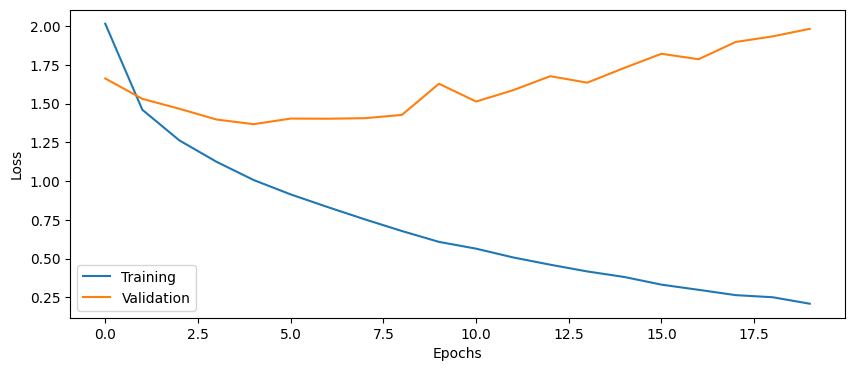

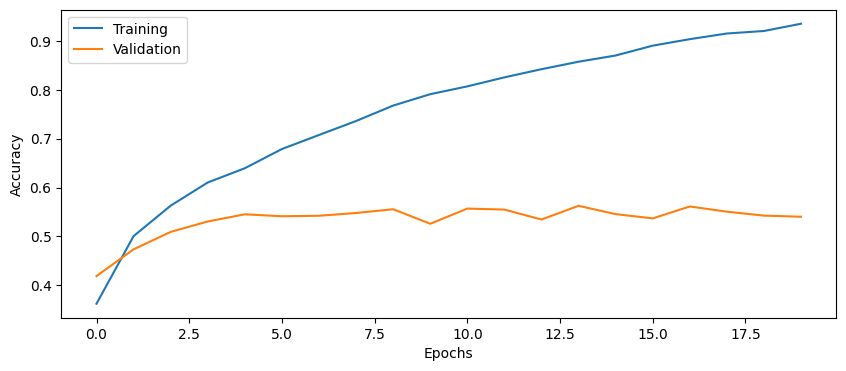

In [20]:
from utilities import plot_results
# Plot the history from the training run
plot_results(history1)

##  4.3 Improving model performance

Write down the test accuracy, are you satisfied with the classifier performance (random chance is 10%)? 

#### **<span style="color:red">Questions</span>**
13. How big is the difference between training and test accuracy?

14. For the DNN elaboration we used a batch size of 10.000, why do we need to use a smaller batch size in this elaboration?

#### **<span style="color:green">Answers</span>**
13. Train Accuracy = 93%  
Test accuracy = 55%  
There is approximately 40% different in accuracy  
  
14. CNN requires significantly more memory per batch than simple DNN, since images uses more storage. An image describes multiple dimensions and often in multiple channels compared to observations used in DNN which only contains a vector. Therefore if the batch size is 10,000 it might be to big for the CPU/GPU to process

Experiment with several model configurations in the following sections. 

### 2 convolutional layers with 16 starting filters and 1 intermediate dense layer (50 nodes)

Epoch 1/20
350/350 [==============================] - 4s 8ms/step - loss: 1.8019 - accuracy: 0.3716 - val_loss: 1.7832 - val_accuracy: 0.3363
Epoch 2/20
350/350 [==============================] - 3s 9ms/step - loss: 1.4414 - accuracy: 0.4874 - val_loss: 1.3992 - val_accuracy: 0.5017
Epoch 3/20
350/350 [==============================] - 3s 9ms/step - loss: 1.2858 - accuracy: 0.5431 - val_loss: 1.3275 - val_accuracy: 0.5340
Epoch 4/20
350/350 [==============================] - 3s 8ms/step - loss: 1.1655 - accuracy: 0.5863 - val_loss: 1.3030 - val_accuracy: 0.5530
Epoch 5/20
350/350 [==============================] - 3s 9ms/step - loss: 1.0622 - accuracy: 0.6306 - val_loss: 1.2956 - val_accuracy: 0.5503
Epoch 6/20
350/350 [==============================] - 3s 8ms/step - loss: 0.9897 - accuracy: 0.6546 - val_loss: 1.3827 - val_accuracy: 0.5287
Epoch 7/20
350/350 [==============================] - 3s 8ms/step - loss: 0.8949 - accuracy: 0.6956 - val_loss: 1.3138 - val_accuracy: 0.5547
Epoch 

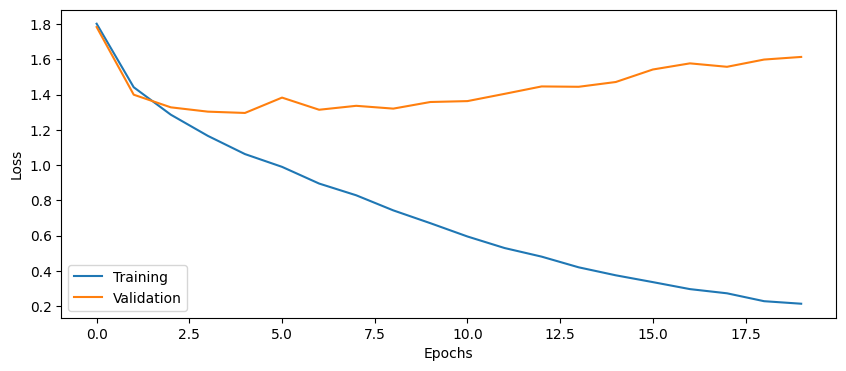

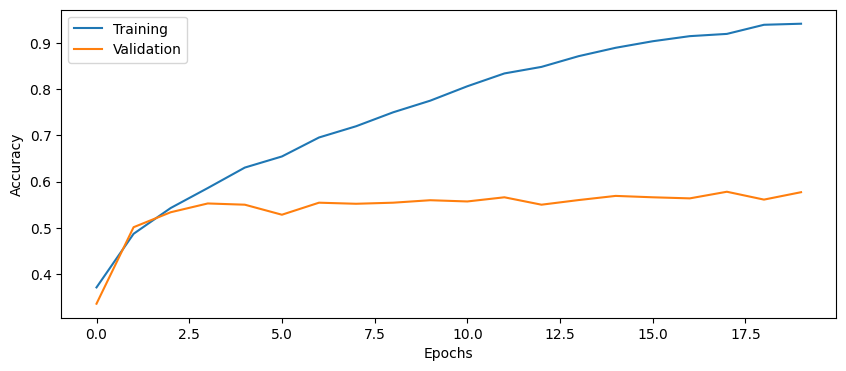

In [21]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------
batch_size = 20
epochs = 20
input_shape = Xtrain.shape[1:]
learning_rate = 0.01
n_conv_layers = 2
n_filters = 16
n_dense_layers=1
n_nodes=50

loss = CategoricalCrossentropy()
validation_data=(Xval, Yval)

# Build and train model
model1 = build_CNN(input_shape=input_shape,
                  loss=loss,
                  learning_rate=learning_rate,
                  n_conv_layers=n_conv_layers,
                  n_nodes=n_nodes,
                  n_filters=n_filters,
                  n_dense_layers=n_dense_layers)

history1 = model1.fit(Xtrain, Ytrain, batch_size=batch_size, epochs=epochs, validation_data=validation_data)

# Evaluate model on test data

score = model1.evaluate(Xtest, Ytest)

# ============================================

print('Test loss: %.4f' % score[0])
print('Test accuracy: %.4f' % score[1])

# Plot the history from the training run
plot_results(history1)

### 4 convolutional layers with 16 starting filters and 1 intermediate dense layer (50 nodes)

Epoch 1/20
350/350 [==============================] - 6s 14ms/step - loss: 1.8881 - accuracy: 0.3306 - val_loss: 1.9381 - val_accuracy: 0.2937
Epoch 2/20
350/350 [==============================] - 4s 13ms/step - loss: 1.4565 - accuracy: 0.4706 - val_loss: 1.4134 - val_accuracy: 0.4937
Epoch 3/20
350/350 [==============================] - 4s 13ms/step - loss: 1.2797 - accuracy: 0.5443 - val_loss: 1.3420 - val_accuracy: 0.5240
Epoch 4/20
350/350 [==============================] - 4s 12ms/step - loss: 1.1294 - accuracy: 0.6101 - val_loss: 1.3241 - val_accuracy: 0.5367
Epoch 5/20
350/350 [==============================] - 4s 13ms/step - loss: 0.9963 - accuracy: 0.6591 - val_loss: 1.3170 - val_accuracy: 0.5430
Epoch 6/20
350/350 [==============================] - 4s 13ms/step - loss: 0.8592 - accuracy: 0.7047 - val_loss: 1.2730 - val_accuracy: 0.5593
Epoch 7/20
350/350 [==============================] - 4s 13ms/step - loss: 0.7298 - accuracy: 0.7584 - val_loss: 1.3641 - val_accuracy: 0.5387

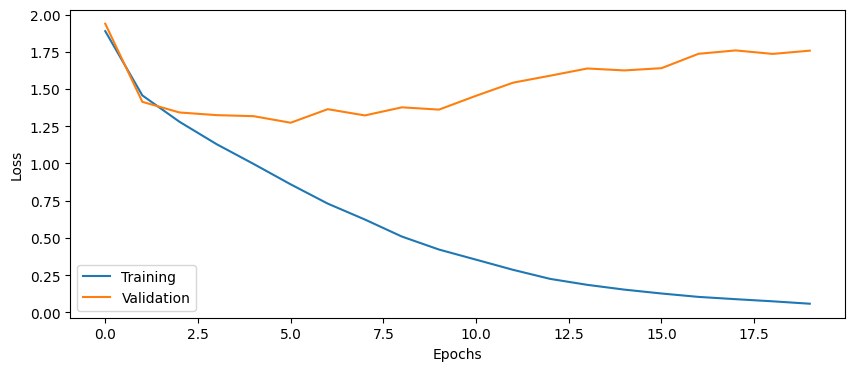

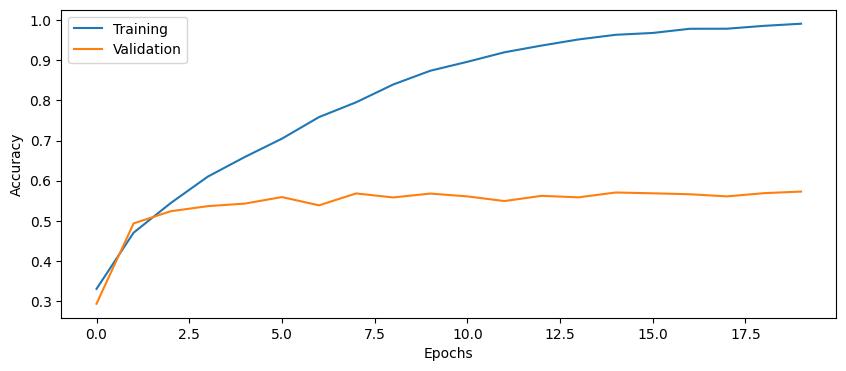

In [22]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------
batch_size = 20
epochs = 20
input_shape = Xtrain.shape[1:]
learning_rate = 0.01
n_conv_layers = 4
n_filters = 16
n_dense_layers=1
n_nodes=50

loss = CategoricalCrossentropy()
validation_data=(Xval, Yval)

# Build and train model
model2 = build_CNN(input_shape=input_shape,
                  loss=loss,
                  learning_rate=learning_rate,
                  n_conv_layers=n_conv_layers,
                  n_nodes=n_nodes,
                  n_filters=n_filters,
                  n_dense_layers=n_dense_layers)

history2 = model2.fit(Xtrain, Ytrain, batch_size=batch_size, epochs=epochs, validation_data=validation_data)

# Evaluate model on test data

score = model2.evaluate(Xtest, Ytest)

# ============================================

print('Test loss: %.4f' % score[0])
print('Test accuracy: %.4f' % score[1])

# Plot the history from the training run
plot_results(history2)

## 4.4 Plot the CNN architecture and understand the internal model dimensions

To understand your network better, print the architecture using `model.summary()`

#### **<span style="color:red">Questions</span>**

15. How many trainable parameters does your network have? Which part of the network contains most of the parameters?
    
16. What is the input to and output of a Conv2D layer? What are the dimensions of the input and output? 
17. Is the batch size always the first dimension of each 4D tensor? Check the [documentation](https://keras.io/layers/convolutional/) for Conv2D.
18. If a convolutional layer that contains 128 filters is applied to an input with 32 channels, what is the number of channels in the output?
19. Why is the number of parameters in each Conv2D layer *not* equal to the number of filters times the number of filter coefficients per filter (plus biases)?
20. How does MaxPooling help in reducing the number of parameters to train?

#### **<span style="color:green">Answers</span>**
15. Trainable parameters: 124,180. Conv2d contains most of the parameters.  
  
16. The input: (batch_size, height, width, channels).  
For model 2, the input dimension is: (20, 32, 32, 3).  
The output: (batch_size, new_height, new_width, filters).  
For model 2, the output dimension is: (20, 32, 32, 16).  

17. Yes.
If data_format="channels_last":  
input: (batch_size, height, width, channels)  
output: (batch_size, new_height, new_width, filters)  

If data_format="channels_first":  
input: (batch_size, channels, height, width)  
output: (batch_size, filters, new_height, new_width)  

18. 128 channels. Because the number of output channels is equal to the number of filters, regardless of input channels.  

19. Because each filter has one 3D kernel (3, 3, 16). Therefore 32 × 3 × 3 × 16 + 32 = 4640

20. By reducing the size of the feature map by taking the maximum value of small segments.

In [23]:
model2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 32, 32, 16)        448       
                                                                 
 batch_normalization_7 (Bat  (None, 32, 32, 16)        64        
 chNormalization)                                                
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 16, 16, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 16, 16, 32)        4640      
                                                                 
 batch_normalization_8 (Bat  (None, 16, 16, 32)        128       
 chNormalization)                                                
                                                      

##  4.5 Dropout regularization

Add dropout regularization between each intermediate dense layer, with dropout probability 50%.

#### **<span style="color:red">Questions</span>**

21. How much did the test accuracy improve with dropout, compared to without dropout?

22. What other types of regularization can be applied? How can you add `L2 regularization` for the convolutional layers?
 
#### **<span style="color:green">Answers</span>**
21. Without droput: Test accuracy: 0.5385  
With dropout: Test accuracy: 0.5870

22. Regularizations that can be used: L1, L2, combined L1 L2, activity regularization
by adding regularizers.L2() in kernel_regularizer argument for Conv2D


### 4 convolutional layers with 16 starting filters and 1 intermediate dense layer (50 nodes) with dropout

Epoch 1/20
350/350 [==============================] - 6s 14ms/step - loss: 2.2618 - accuracy: 0.2690 - val_loss: 1.8304 - val_accuracy: 0.3223
Epoch 2/20
350/350 [==============================] - 6s 16ms/step - loss: 1.7827 - accuracy: 0.3690 - val_loss: 1.4944 - val_accuracy: 0.4697
Epoch 3/20
350/350 [==============================] - 6s 17ms/step - loss: 1.5809 - accuracy: 0.4276 - val_loss: 1.4795 - val_accuracy: 0.4687
Epoch 4/20
350/350 [==============================] - 5s 14ms/step - loss: 1.4605 - accuracy: 0.4837 - val_loss: 1.3414 - val_accuracy: 0.5207
Epoch 5/20
350/350 [==============================] - 6s 16ms/step - loss: 1.3610 - accuracy: 0.5151 - val_loss: 1.3234 - val_accuracy: 0.5203
Epoch 6/20
350/350 [==============================] - 5s 15ms/step - loss: 1.2783 - accuracy: 0.5423 - val_loss: 1.2629 - val_accuracy: 0.5483
Epoch 7/20
350/350 [==============================] - 5s 14ms/step - loss: 1.2167 - accuracy: 0.5647 - val_loss: 1.2633 - val_accuracy: 0.5567

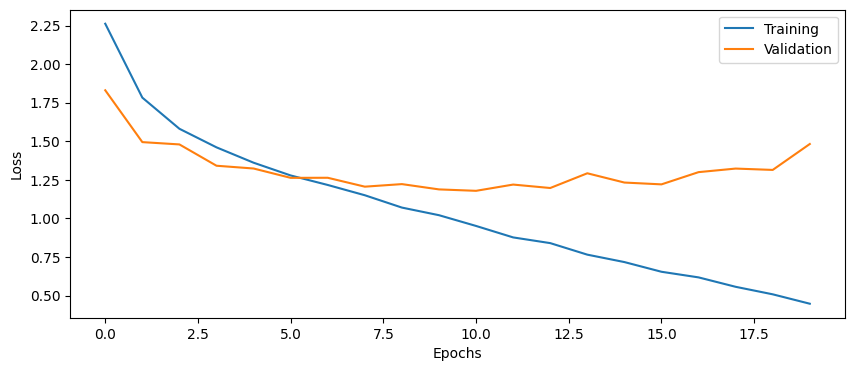

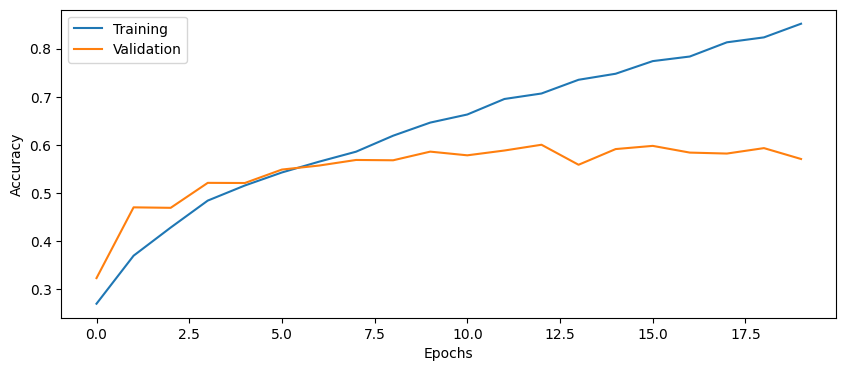

In [24]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------
batch_size = 20
epochs = 20
input_shape = Xtrain.shape[1:]
learning_rate = 0.01
n_conv_layers = 4
n_filters = 16
n_dense_layers=1
n_nodes=50
use_dropout=True

loss = CategoricalCrossentropy()
validation_data=(Xval, Yval)

# Build and train model
model3 = build_CNN(input_shape=input_shape,
                  loss=loss,
                  learning_rate=learning_rate,
                  n_conv_layers=n_conv_layers,
                  n_nodes=n_nodes,
                  n_filters=n_filters,
                  n_dense_layers=n_dense_layers,
                  use_dropout=use_dropout)

history3 = model3.fit(Xtrain, Ytrain, batch_size=batch_size, epochs=epochs, validation_data=validation_data)

# Evaluate model on test data

score = model3.evaluate(Xtest, Ytest)

# ============================================

print('Test loss: %.4f' % score[0])
print('Test accuracy: %.4f' % score[1])

# Plot the history from the training run
plot_results(history3)

##  4.6 Tweaking model performance

You have now seen the basic building blocks of a 2D CNN. To further improve performance involves changing the number of convolutional layers, the number of filters per layer, the number of intermediate dense layers, the number of nodes in the intermediate dense layers, batch size, learning rate, number of epochs, etc. Spend some time (30 - 90 minutes) testing different settings.

#### **<span style="color:red">Questions</span>**

23. How high test accuracy can you obtain? What is your best configuration?

#### **<span style="color:green">Answers</span>**
23. best accuracy = 62%  
configuration:  
batch_size = 10  
epochs = 30  
input_shape = Xtrain.shape[1:]  
learning_rate = 0.01  
n_conv_layers = 5  
n_filters = 32  
n_dense_layers=1  
n_nodes=80  
use_dropout=True  

## *Your best config*

Epoch 1/30
700/700 [==============================] - 30s 41ms/step - loss: 2.1775 - accuracy: 0.2891 - val_loss: 1.5855 - val_accuracy: 0.4263
Epoch 2/30
700/700 [==============================] - 28s 41ms/step - loss: 1.7017 - accuracy: 0.3937 - val_loss: 1.4142 - val_accuracy: 0.5013
Epoch 3/30
700/700 [==============================] - 27s 39ms/step - loss: 1.4919 - accuracy: 0.4653 - val_loss: 1.2886 - val_accuracy: 0.5350
Epoch 4/30
700/700 [==============================] - 24s 35ms/step - loss: 1.3576 - accuracy: 0.5140 - val_loss: 1.2343 - val_accuracy: 0.5613
Epoch 5/30
700/700 [==============================] - 25s 36ms/step - loss: 1.2290 - accuracy: 0.5570 - val_loss: 1.2304 - val_accuracy: 0.5683
Epoch 6/30
700/700 [==============================] - 24s 34ms/step - loss: 1.1350 - accuracy: 0.5924 - val_loss: 1.1496 - val_accuracy: 0.5903
Epoch 7/30
700/700 [==============================] - 25s 35ms/step - loss: 1.0330 - accuracy: 0.6396 - val_loss: 1.1359 - val_accuracy:

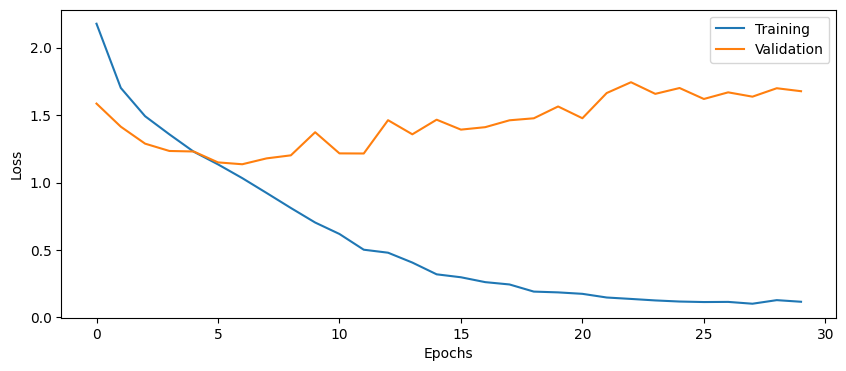

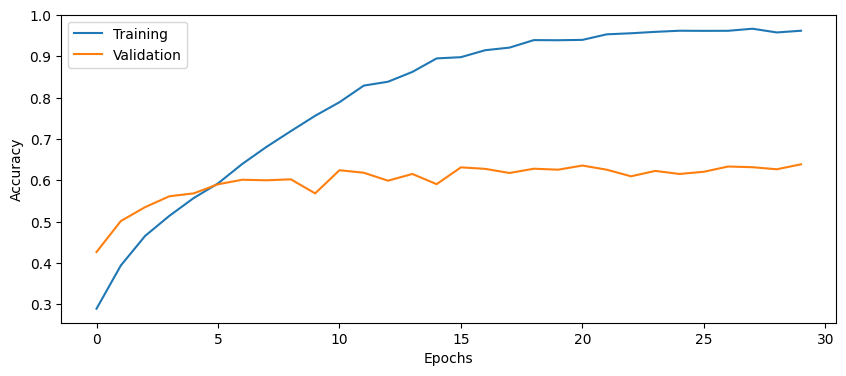

In [25]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------
batch_size = 10
epochs = 30
input_shape = Xtrain.shape[1:]
learning_rate = 0.01
n_conv_layers = 5
n_filters = 32
n_dense_layers=1
n_nodes=80
use_dropout=True

loss = CategoricalCrossentropy()
validation_data=(Xval, Yval)

# Build and train model
model4 = build_CNN(input_shape=input_shape,
                  loss=loss,
                  learning_rate=learning_rate,
                  n_conv_layers=n_conv_layers,
                  n_nodes=n_nodes,
                  n_filters=n_filters,
                  n_dense_layers=n_dense_layers,
                  use_dropout=use_dropout)

history4 = model4.fit(Xtrain, Ytrain, batch_size=batch_size, epochs=epochs, validation_data=validation_data)

# Evaluate model on test data

score = model4.evaluate(Xtest, Ytest)

# ============================================

print('Test loss: %.4f' % score[0])
print('Test accuracy: %.4f' % score[1])

# Plot the history from the training run
plot_results(history4)

# Part 5: Model generalization

How high is the test accuracy if we rotate the test images? In other words, how good is the CNN at generalizing to rotated images?

Rotate each test image 90 degrees, the cells are already finished.

#### **<span style="color:red">Questions</span>**

24. What is the test accuracy for rotated test images, compared to test images without rotation? Explain the difference in accuracy.

#### **<span style="color:green">Answers</span>**
24. Test accuracy drop significantly from 63% to 24%. The reason why this happens is because the model is trained with upright images, therefore when the images are rotated, the edges and shapes do not match the patterns model have learned.

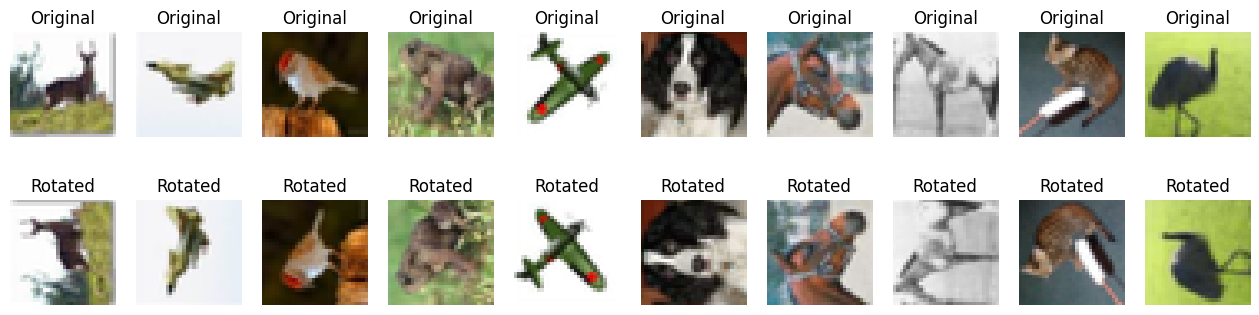

In [26]:
from utilities import myrotate
# Visualize some rotated images
# Rotate the test images 90 degrees
Xtest_rotated = myrotate(Xtest)

# Look at some rotated images
plt.figure(figsize=(16,4))
for i in range(10):
    idx = np.random.randint(500)
    
    plt.subplot(2,10,i+1)
    plt.imshow(Xtest[idx]/2+0.5)
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(2,10,i+11)
    plt.imshow(Xtest_rotated[idx]/2+0.5)
    plt.title("Rotated")
    plt.axis('off')
plt.show()


In [27]:
# Evaluate the trained model on rotated test set
score = model4.evaluate(Xtest_rotated, Ytest, verbose=0)
print('Test loss: %.4f' % score[0])
print('Test accuracy: %.4f' % score[1])

Test loss: 4.7809
Test accuracy: 0.2185


##  5.1 Augmentation using Keras `ImageDataGenerator`

We can increase the number of training images through data augmentation (we now ignore that CIFAR10 actually has 60 000 training images). Image augmentation is about creating similar images, by performing operations such as rotation, scaling, elastic deformations and flipping of existing images. This will prevent overfitting, especially if all the training images are in a certain orientation.

We will perform the augmentation on the fly, using a built-in function in Keras, called `ImageDataGenerator`. In particular, we will use the `flow()` functionality (see the [documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator) for more details).

Make sure to use different subsets for training and validation when you calling `flow()` on the training data generator in `model.fit()`, otherwise you will validate on the same data. 

In [28]:
# Get all 60 000 training images again. ImageDataGenerator manages validation data on its own

# re-load the CIFAR10 train and test data
(X, Y), (Xtest, Ytest) = cifar10.load_data()

# Reduce the number of images for training/validation and testing to 10000 and 2000 respectively, 
# to reduce processing time for this elaboration. 
X = X[0:10000]
Y = Y[0:10000]

Xtest = Xtest[0:2000]
Ytest = Ytest[0:2000]

# Change data type and rescale range
X = X.astype('float32')
Xtest = Xtest.astype('float32')

X = X / 127.5 - 1
Xtest = Xtest / 127.5 - 1


# Convert labels to hot encoding
Y = to_categorical(Y, 10)
Ytest = to_categorical(Ytest, 10)

print("Training/validation images have size {} and labels have size {} ".format(X.shape, Y.shape))
print("Test images have size {} and labels have size {} \n ".format(Xtest.shape, Ytest.shape))

Training/validation images have size (10000, 32, 32, 3) and labels have size (10000, 10) 
Test images have size (2000, 32, 32, 3) and labels have size (2000, 10) 
 


In [29]:
from tf_keras.preprocessing.image import ImageDataGenerator

# --------------------------------------------
# === Your code here =========================
# --------------------------------------------

# Use a rotation range of 30 degrees, horizontal and vertical flipping
# Set up image data generator
image_dataset = ImageDataGenerator(rotation_range=30, 
                                   horizontal_flip=True,
                                   vertical_flip=True)


# ============================================
Xtrain, Xval, Ytrain, Yval = train_test_split(X, Y, test_size=0.3, random_state=123, stratify=Y.argmax(axis=1))

train_flow = image_dataset.flow(Xtrain, Ytrain, batch_size=10, shuffle=True)


#### **<span style="color:red">Questions</span>**

25. How would you change the code for the image generator if you cannot fit all training images in CPU memory? What is the disadvantage of doing that change?

#### **<span style="color:green">Answers</span>**
25. If the full training set cannot fit in CPU memory, we use ImageDataGenerator.flow_from_directory() so the images would be read from disk instead being loaded from RAM. The disadvantage would be slower training, since accessing the disk is much slower than the RAM.

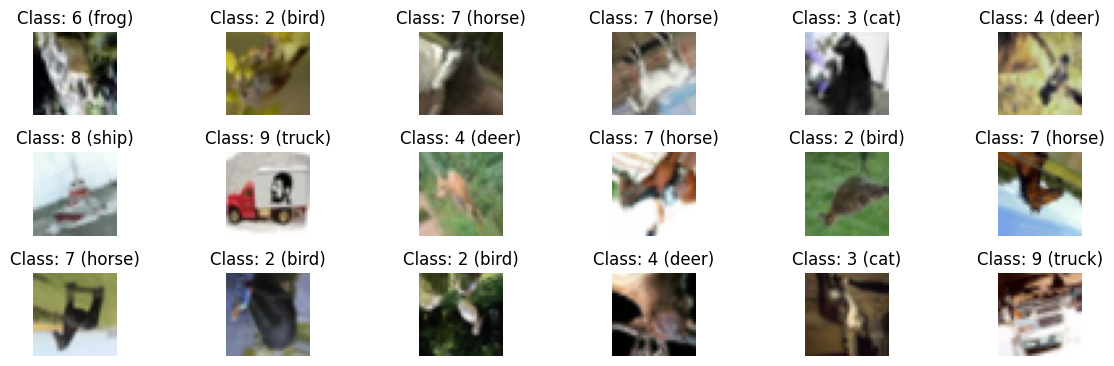

In [30]:
# Plot some augmented images

plt.figure(figsize=(12,4))
for i in range(18):
    (im, label) = train_flow.next()
    im = (im[0] + 1) * 127.5
    im = im.astype('int')
    label = np.flatnonzero(label)[0]
    
    plt.subplot(3,6,i+1)
    plt.tight_layout()
    plt.imshow(im)
    plt.title("Class: {} ({})".format(label, classes[label]))
    plt.axis('off')
plt.show()

## 5.2 Train the CNN with images from the generator

Check the documentation for the [`model.fit`](https://keras.io/api/models/model_training_apis/#fit-method) method how to use it with a generator instead of a fix dataset (numpy arrays).

To make the comparison fair to training without augmentation

- `steps_per_epoch` should be set to: `len(Xtrain)/batch_size`
- `validation_steps` should be set to: `len(Xval)/batch_size`
    
This is required since with a generator, the fit function will not know how many examples your original dataset has.

#### **<span style="color:red">Questions</span>**

26. How quickly is the training accuracy increasing compared to without augmentation? Explain why there is a difference compared to without augmentation. We are here talking about the number of training epochs required to reach a certain accuracy, and not the training time in seconds. What parameter is necessary to change to perform more training?

27. What other types of image augmentation can be applied, compared to what we use here?

#### **<span style="color:green">Answers</span>**
26. The training accuracy increasing significantly more slowly compared to without augmentation. This is because training batches contain randomly transformed images. Thus the model need more epochs to reach the same accuracy. "Epochs" change is needed to perform more training.

27. Other type of augmentations: Cropping (Zoom in or zoom out), skewing, warping, intesify or blur, brightness or saturation change

In [31]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------

# Setup training parameters
batch_size = 10
epochs = 30
input_shape = Xtrain.shape[1:]
learning_rate = 0.01
n_conv_layers = 5
n_filters = 32
n_dense_layers=1
n_nodes=80
use_dropout=True
steps_per_epoch=len(Xtrain)/batch_size
validation_steps=len(Xval)/batch_size
loss = CategoricalCrossentropy()

# Build model (your best config)
model6 = build_CNN(input_shape=input_shape,
                  loss=loss,
                  learning_rate=learning_rate,
                  n_conv_layers=n_conv_layers,
                  n_nodes=n_nodes,
                  n_filters=n_filters,
                  n_dense_layers=n_dense_layers,
                  use_dropout=use_dropout)

# Set up training and validation dataset flows from image_dataset
# flow() for training data
train_flow = image_dataset.flow(Xtrain, Ytrain, batch_size=batch_size, shuffle=True)

# flow() for validation data
val_flow = image_dataset.flow(Xval, Yval, batch_size=batch_size, shuffle=True)


# Train the model using on the fly augmentation
history6 = model6.fit(train_flow,
                      batch_size=batch_size,
                      epochs=epochs,
                      validation_data=val_flow,
                      steps_per_epoch=steps_per_epoch,
                      validation_steps=validation_steps)

# ============================================

Epoch 1/30
700/700 [==============================] - 28s 37ms/step - loss: 2.4492 - accuracy: 0.2043 - val_loss: 1.8569 - val_accuracy: 0.3250
Epoch 2/30
700/700 [==============================] - 153s 218ms/step - loss: 1.9710 - accuracy: 0.2939 - val_loss: 1.6962 - val_accuracy: 0.3630
Epoch 3/30
700/700 [==============================] - 27s 38ms/step - loss: 1.8498 - accuracy: 0.3231 - val_loss: 1.6697 - val_accuracy: 0.3883
Epoch 4/30
700/700 [==============================] - 27s 39ms/step - loss: 1.7540 - accuracy: 0.3634 - val_loss: 1.5502 - val_accuracy: 0.4383
Epoch 5/30
700/700 [==============================] - 26s 37ms/step - loss: 1.7078 - accuracy: 0.3850 - val_loss: 1.5406 - val_accuracy: 0.4400
Epoch 6/30
700/700 [==============================] - 27s 38ms/step - loss: 1.6683 - accuracy: 0.3917 - val_loss: 1.4696 - val_accuracy: 0.4723
Epoch 7/30
700/700 [==============================] - 26s 38ms/step - loss: 1.6167 - accuracy: 0.4201 - val_loss: 1.4665 - val_accurac

In [32]:
# Check if there is still a big difference in accuracy for original and rotated test images

# Evaluate the trained model on original test set
score = model6.evaluate(Xtest, Ytest, batch_size = batch_size, verbose=0)
print('Original test:')
print('Test loss: %.4f' % score[0])
print('Test accuracy: %.4f' % score[1])

# Evaluate the trained model on rotated test set
score = model6.evaluate(Xtest_rotated, Ytest, batch_size = batch_size, verbose=0)
print('Rotated test set')
print('Test loss: %.4f' % score[0])
print('Test accuracy: %.4f' % score[1])

Original test:
Test loss: 1.2099
Test accuracy: 0.5830
Rotated test set
Test loss: 2.3615
Test accuracy: 0.2960


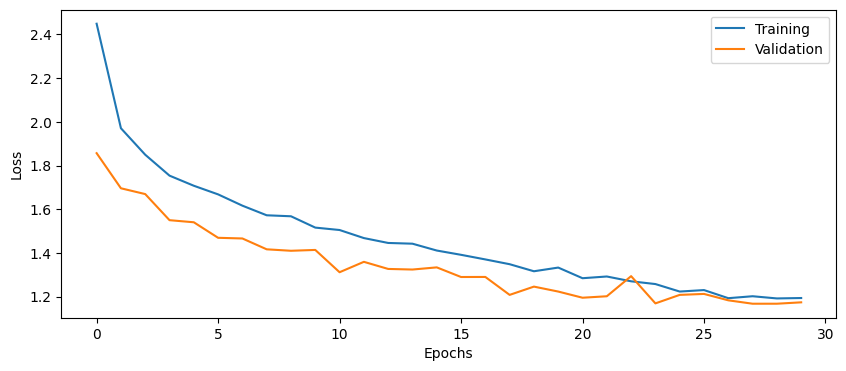

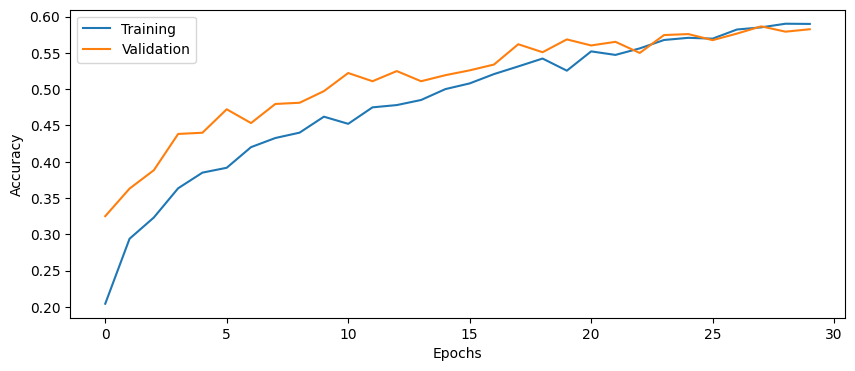

In [33]:
# Plot the history from the training run
plot_results(history6)

## Plot misclassified images

Lets plot some images where the CNN performed badly.

In [34]:
# Find misclassified images
y_pred=model6.predict(Xtest, verbose=0) 
y_pred=np.argmax(y_pred,axis=1)

y_correct = np.argmax(Ytest,axis=-1)

miss = np.flatnonzero(y_correct != y_pred)

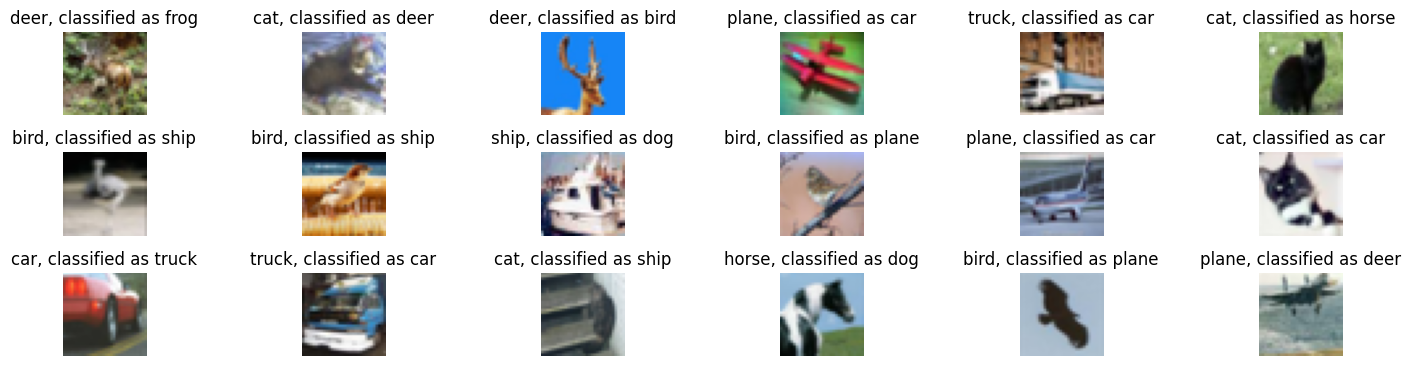

In [34]:
# Plot a few of them
plt.figure(figsize=(15,4))
perm = np.random.permutation(miss)
for i in range(18):
    im = (Xtest[perm[i]] + 1) * 127.5
    im = im.astype('int')
    label_correct = y_correct[perm[i]]
    label_pred = y_pred[perm[i]]
    
    plt.subplot(3,6,i+1)
    plt.tight_layout()
    plt.imshow(im)
    plt.axis('off')
    plt.title("{}, classified as {}".format(classes[label_correct], classes[label_pred]))
plt.show()

##  5.3 Testing on another size

#### **<span style="color:red">Questions</span>**

28. This CNN has been trained on 32 x 32 images, can it be applied to images of another size? If not, why is this the case?

29. Is it possible to design a CNN that can be trained on images of one size, and then applied to an image of any size? How?

#### **<span style="color:green">Answers</span>**
28. No, it cannot. Because flatten() converts feature into a certain length vector while the dense layer only expect a fixed number of input units.  
  
29. Yes. By using GlobalAveragePooling2D() instead of Flatten() and removing the dense layer (full convolutional).

# Part 6: Carbon footprint

In this next section we will evaluate the carbon footprint of training our CNN model. In particular we will look at the effect of training hyper parameters of carbon footprint. You can read more about this topic [here](https://arxiv.org/abs/2007.03051) or [here](https://research.google/blog/good-news-about-the-carbon-footprint-of-machine-learning-training/). 

In this lab we will use the `carbontracker` library that easily integrates with any model training routine. See the example in the [documentation](https://github.com/lfwa/carbontracker?tab=readme-ov-file) on how to use the carbon tracker.

#### **<span style="color:red">Questions</span>**

28. Keeping the model architecture fixed, which training parameter impacts the carbon footprint? 
    
29. The choice of batch size can dramatically impact carbon foot print: why is this the case?
    
30. Assume that you have a model with 100 million parameters running in the backend of a service with 5 million users. How can the carbon footprint of using this model be reduced?

#### **<span style="color:green">Answers</span>**
28. Number of epochs is the parameter with the biggest impact on carbon footprint. Other parameter that impacting carbon footprint are batch size and learning size.  
  
29. Batch size changes the number of update steps per epoch, which can directly increase computational cost.
  
30. Use model compression such as pruning, use pretrained model such as resnet, use cache for repeated queries.

In [35]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------
# Setup training parameters
batch_size = 4
epochs = 30
input_shape = Xtrain.shape[1:]
learning_rate = 0.01
n_conv_layers = 5
n_filters = 32
n_dense_layers=1
n_nodes=80
use_dropout=True
validation_data=(Xval, Yval)
loss = CategoricalCrossentropy()

# Build model (your best config)
model7 = build_CNN(input_shape=input_shape,
                  loss=loss,
                  learning_rate=learning_rate,
                  n_conv_layers=n_conv_layers,
                  n_nodes=n_nodes,
                  n_filters=n_filters,
                  n_dense_layers=n_dense_layers,
                  use_dropout=use_dropout)
# ============================================


In [36]:
from carbontracker.tracker import CarbonTracker

# Create a CarbonTracker object
tracker = CarbonTracker(
    epochs=epochs,
    ignore_errors=True
)

for epoch in range(epochs):
# start carbon tracking
    tracker.epoch_start()
# fit model
    model7.fit(Xtrain,
            Ytrain,
            batch_size=batch_size,
            epochs=1,
            validation_data=val_flow,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps)
    tracker.epoch_end()
tracker.stop()

CarbonTracker: INFO - Detected CPU: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
CarbonTracker: WARNING - No matching TDP found for CPU: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz. Using average TDP of 35.61W at 50% utilization as fallback.
CarbonTracker: WARNING - No API keys provided. Skipping intensity provider initialization.
CarbonTracker: The following components were found: CPU with device(s) Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz.
CarbonTracker: WARNING - No carbon intensity provider specified. Using average carbon intensity for SE: 35.82 gCO2eq/kWh.
700/700 [==============================] - 29s 38ms/step - loss: 2.5468 - accuracy: 0.1768 - val_loss: 2.1576 - val_accuracy: 0.2327
CarbonTracker: 
Predicted consumption for 30 epoch(s):
	Time:	0:14:38
	Energy:	0.013730225340 kWh
	CO2eq:	0.491869299641 g
	This is equivalent to:
	0.004605517787 km travelled by car
700/700 [==============================] - 30s 43ms/step - loss: 1.2042 - accuracy: 0.5993 - val_loss: 2.1337 - val_accu

# Part 7: Pre-trained 2D CNNs

There are many deep 2D CNNs that have been pre-trained using the large ImageNet database (several million images, 1000 classes). Import a pre-trained ResNet50 network from Keras applications. Show the network using `model.summary()`

#### **<span style="color:red">Questions</span>**

31. How many convolutional layers does ResNet50 have? 

32. How many trainable parameters does the ResNet50 network have? 

33. What is the size of the images that ResNet50 expects as input?

34. Using the answer to question 30, explain why the second derivative is seldom used when training deep networks.

35. What do you expect the carbon footprint of using pre-trained networks to be compared to training a model from scratch?

#### **<span style="color:green">Answers</span>**
31. 49 convulational layers, plus 1 fully connected layer  
  
32. 25,583,592 trainable parameters for this specific model
  
33. 224 × 224 × 3.  
  
34. Because the hessian matrix would be really big. If it's 1 million parameters, the matrix will be 1 million x 1 million
  
35. Using pre-trained model will significantly reduce carbon footprint. Because only one forward pass per inference is needed and no backpropagation


After loading the pre-trained CNN, apply it to 5 random color images that you download and copy to the cloud machine or your own computer. Are the predictions correct? How certain is the network of each image class?

These pre-trained networks can be fine tuned to your specific data, and normally only the last layers need to be re-trained, but it will still be too time consuming to do in this elaboration.

Some useful functions:
- `load_img` and `img_to_array` in [tf_keras.utils](https://www.tensorflow.org/api_docs/python/tf/keras/utils).
- `ResNet50` in [tf_keras.applications.ResNet50](tf.keras.applications.ResNet50).
- `preprocess_input` in [tf_keras.applications.resnet](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input).
- `decode_predictions` in [tf_keras.applications.resnet](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/decode_predictions).
- `expand_dims` in [numpy](https://numpy.org/doc/stable/reference/generated/numpy.expand_dims.html).

See [keras applications](https://keras.io/api/applications/) and the keras [resnet50-function](https://keras.io/api/applications/resnet/#resnet50-function) for more details.

In [39]:
# --------------------------------------------
# === Your code here =========================
# --------------------------------------------
# import the necessary libraries and functions 
from tf_keras.applications import ResNet50
from tf_keras.utils import load_img, img_to_array
from tf_keras.applications.resnet import preprocess_input, decode_predictions

# load the pre-trained ResNet50 model
resnet50 = ResNet50(weights="imagenet")


# print the model summary


# load the image and preprocess it
image = ["images/cat_august.jpg",
               "images/laptop.jpg",    
               "images/microwave_oven.jpg",    
               "images/ramen_shrimp.jpg",   
               "images/sneakers.jpeg",]



for path in image:

    img = load_img(path, target_size=(224, 224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)


    preds = resnet50.predict(x, verbose=0)

    # predict the image
    label = decode_predictions(preds, top=1)[0][0][1]
    prob  = decode_predictions(preds, top=1)[0][0][2]

    # print the predicted label
    print(f"Image: {path}")
    print(label)
    print("------")



# ============================================

Image: images/cat_august.jpg
tabby
------
Image: images/laptop.jpg
notebook
------
Image: images/microwave_oven.jpg
space_heater
------
Image: images/ramen_shrimp.jpg
hot_pot
------
Image: images/sneakers.jpeg
running_shoe
------


In [38]:
resnet50.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_2[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

# Part 8 (OPTIONAL)

Set up `Ray Tune` and run automatic hyper parameter optimization for the CNN model as we have done in the DNN lab. Remember that you have to define the `train_CNN` function, specify the hyper parameter search space and the number of samples to evaluate, among other.